# 05c — RAG, Approach C: hybrid (fuse A + B)

*Fuses Approach A and Approach B.* Approach A (Semantic-ID + multi-stage) retrieves **behaviourally** similar precedents — borrowers like this one. Approach B (full-corpus kNN) retrieves **globally** similar precedents — loans like this one. They surface different evidence, so this notebook runs **both** and fuses their rankings with **Reciprocal Rank Fusion (RRF)** before injecting the top-`K_PRECEDENTS`.

This mirrors how production RAG stacks combine an ID/structured retriever with a dense retriever. **Section 4 is the decision aid**: it measures how much A and B actually overlap — if they retrieve nearly the same precedents the hybrid adds little; if they diverge, fusion should help.

Compared against **A**, **B**, a **no-RAG LLM**, and **XGBoost** on the same evaluation loans. Evaluation runs on **two batches** — `robustness_batch` (validation) **and** `tuning_sample` — reported per batch and pooled (200 loans, ~24 defaults). The held-out `test_batch` is reserved for Phase 4.

## Setup & config

The first cell pins OpenMP to a single thread, because torch (via sentence-transformers) and XGBoost otherwise load competing runtimes and segfault the kernel on macOS, so it has to run before any other import. The config lines below it set the provider and model, the embedding backend, how many precedents to inject per loan, and `N_TEST`, which caps the run to a handful of loans for a cheap smoke test before paying for the full batch.

In [1]:
import os
# torch (sentence-transformers) and XGBoost each ship their own OpenMP runtime; on
# macOS loading both in one kernel segfaults. Pin to a single shared OpenMP thread
# BEFORE importing either — this must run before the llm_utils/rag_utils imports below.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys; sys.path.insert(0, '..')
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from llm_utils import (
    run_llm_experiment, run_ml_on_sample, evaluate_predictions,
    build_system_prompt, build_user_prompt, load_all_api_keys, RESULTS_DIR,
)
from sample_generation import get_robustness_batch, get_tuning_sample, get_rag_corpus
import rag_utils as R

# ── Config — change these to switch provider / backend ──────────────
API_PROVIDER      = 'openai'                       # GPT-5.4 — the project's chosen model
MODEL_NAME        = 'gpt-5.4'
MODEL_LABEL       = 'GPT-5.4'
EMBEDDING_BACKEND = 'auto'                         # sentence-transformers if installed, else TF-IDF
K_PRECEDENTS      = 8                              # precedents injected per loan (after fusion)
N_STAGE1          = 50                             # stage-1 pool (Approach A)
N_FUSE            = 20                             # candidates each retriever contributes to RRF
RRF_K             = 60                             # RRF damping constant (standard 60)
RRF_WEIGHTS       = (1.0, 1.0)                     # (Approach A weight, Approach B weight)
N_TEST            = None                           # e.g. 50 for a quick smoke run; None = full batches
FORCE_RERUN       = False                          # True ignores the call cache AND recomputes the
                                                   # no-RAG baselines. False is safe here: cache keys
                                                   # include the batch name, so tuning/robustness runs
                                                   # never collide, and a finished run is resumed free.
NOTEBOOK_ID       = '05c_RAG_Hybrid.ipynb'
WITH_LOGPROBS     = API_PROVIDER in ('openai', 'nvidia', 'gemini')

# Parallel per-loan calls fanned out across every key in .env (same pattern as 01a/01b).
API_KEYS    = load_all_api_keys(API_PROVIDER)
MAX_WORKERS = max(1, len(API_KEYS) * 4)  # len(keys) × 4 workers; lower this if you hit 429s
print(f'{len(API_KEYS)} API key(s) for {API_PROVIDER}; MAX_WORKERS={MAX_WORKERS}')

10 API key(s) for openai; MAX_WORKERS=40


In [2]:
# One-time: install the embedding backend if needed (pulls torch).
# Uncomment, run once, then restart the kernel.
# %pip install sentence-transformers
try:
    import sentence_transformers  # noqa: F401
    print('sentence-transformers available')
except Exception:
    print('sentence-transformers NOT installed — Embedder will fall back to TF-IDF.')

sentence-transformers available


## 1. Corpus + evaluation sets (leakage-checked)
Evaluation runs on **two batches**: the `robustness_batch` (validation) **and** the `tuning_sample` as a second eval set — legitimate because the full-frame corpus excludes it too, and the RAG-vs-no-RAG comparison is a paired delta (both arms share the same prompt).

⚠️ Evaluating on the tuning batch **requires the real corpus** (run `00_Build_RAG_Dataset` with the raw `.csv.gz` present) — with the dev-fallback corpus the leakage check will, correctly, refuse to run. The held-out `test_batch` is reserved for Phase 4 and never loaded here.

In [3]:
corpus = get_rag_corpus()          # all loans EXCEPT the eval/test batches

# TWO evaluation batches. Strict-holdout protocol: test_batch.csv is touched
# ONLY in Phase 4 (04_Final_Test_Analysis), never here.
EVAL_BATCHES = {
    'robustness': get_robustness_batch(),   # validation batch (original Phase-5 eval set)
    'tuning':     get_tuning_sample(),      # second eval set (corpus excludes it too)
}
if N_TEST:
    EVAL_BATCHES = {k: df.iloc[:N_TEST].reset_index(drop=True)
                    for k, df in EVAL_BATCHES.items()}

for bname, df in EVAL_BATCHES.items():
    try:
        R.assert_no_leakage(corpus, df)
    except AssertionError as e:
        raise AssertionError(
            f"[eval batch: {bname}] {e}\n"
            "If the corpus is the ~100-row dev fallback it IS the tuning sample — "
            "run 00_Build_RAG_Dataset (raw .csv.gz required) to build the real corpus "
            "before evaluating on the tuning batch."
        ) from e
    print(f"Eval[{bname}]: {len(df)} loans, "
          f"{int((df['loan_status'] == 0).sum())} defaults  (no corpus overlap)")
print(f'Corpus={len(corpus)}')

Eval[robustness]: 100 loans, 9 defaults  (no corpus overlap)
Eval[tuning]: 100 loans, 15 defaults  (no corpus overlap)
Corpus=260579


/Users/alemz/Projects/Github/Sabadell_Capstone/notebooks/llm_models/05_rag/../sample_generation.py:180: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


## 2. Embeddings for BOTH retrievers
Approach A needs the borrower/loan views + Semantic IDs; Approach B needs one flat full-feature index. We build all three here.

In [4]:
# Corpus embeddings are built ONCE; each eval batch is projected into the same spaces.
# --- Approach A spaces: borrower view (behavioural) + loan view (market) ---
emb_b = R.Embedder(backend=EMBEDDING_BACKEND)
b_corpus = emb_b.fit_transform(R.serialize_frame(corpus, R.BORROWER_FEATURES))
b_eval = {bname: emb_b.transform(R.serialize_frame(df, R.BORROWER_FEATURES))
          for bname, df in EVAL_BATCHES.items()}

emb_l = R.Embedder(backend=EMBEDDING_BACKEND)
l_corpus = emb_l.fit_transform(R.serialize_frame(corpus, R.LOAN_FEATURES))
l_eval = {bname: emb_l.transform(R.serialize_frame(df, R.LOAN_FEATURES))
          for bname, df in EVAL_BATCHES.items()}

quant = R.ResidualKMeansQuantizer(n_levels=3, codebook_size=8).fit(b_corpus)
corpus_bsids = quant.semantic_ids(b_corpus)
eval_bsids = {bname: quant.semantic_ids(emb) for bname, emb in b_eval.items()}

# --- Approach B space: one flat full-feature index ---
emb_f = R.Embedder(backend=EMBEDDING_BACKEND)
f_corpus = emb_f.fit_transform(R.serialize_frame(corpus))
f_eval = {bname: emb_f.transform(R.serialize_frame(df))
          for bname, df in EVAL_BATCHES.items()}

print('backend:', emb_f._resolved,
      '| borrower', b_corpus.shape, '| loan', l_corpus.shape, '| full', f_corpus.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

backend: sentence-transformers | borrower (260579, 384) | loan (260579, 384) | full (260579, 384)


## 3. Run both retrievers, fuse with RRF
Per test loan: Approach A produces a ranked list (multi-stage), Approach B produces a ranked list (flat kNN); RRF merges them and we keep the top `K_PRECEDENTS`. We also stash each retriever's own top-K to measure their overlap in Section 4.

In [5]:
def rank_A(bname, i, n):
    # Approach A: behavioural Semantic-ID pool -> loan-view re-rank
    pool_idx, _ = R.semantic_id_retrieve(b_eval[bname][i], eval_bsids[bname][i],
                                         b_corpus, corpus_bsids, k=N_STAGE1)
    idx, _ = R.cosine_topk(l_eval[bname][i], l_corpus, min(n, len(pool_idx)),
                           candidate_idx=pool_idx)
    return list(idx)

def rank_B(bname, i, n):
    # Approach B: flat full-corpus kNN
    idx, _ = R.cosine_topk(f_eval[bname][i], f_corpus, n)
    return list(idx)

blocks, A_sets, B_sets = {}, {}, {}
for bname, df in EVAL_BATCHES.items():
    blocks[bname], A_sets[bname], B_sets[bname] = [], [], []
    for i in range(len(df)):
        a_rank = rank_A(bname, i, N_FUSE)
        b_rank = rank_B(bname, i, N_FUSE)
        fused = R.reciprocal_rank_fusion([a_rank, b_rank], k=RRF_K,
                                         weights=list(RRF_WEIGHTS), top_n=K_PRECEDENTS)
        fused = np.asarray(fused)
        sims = f_corpus[fused] @ f_eval[bname][i]     # overall similarity, for display
        blocks[bname].append(R.build_precedent_block(corpus.iloc[fused], sims=sims))
        A_sets[bname].append(set(a_rank[:K_PRECEDENTS]))
        B_sets[bname].append(set(b_rank[:K_PRECEDENTS]))
    print(f'[{bname}] built {len(blocks[bname])} fused precedent contexts.')
print('\n--- example fused precedent block (robustness loan 0) ---\n')
print(blocks['robustness'][0][:900])

[robustness] built 100 fused precedent contexts.
[tuning] built 100 fused precedent contexts.

--- example fused precedent block (robustness loan 0) ---

RETRIEVED PRECEDENTS — 8 similar past loans with known outcomes:

Precedent 1 — OUTCOME: Fully Paid  [similarity 0.98]
- Loan amount requested ($): 11950.0
- Loan term:  60 months
- Interest rate (%): 23.99
- Monthly payment ($): 343.71
- LC assigned loan grade: F
- LC assigned loan sub-grade: F2
- Home ownership status: RENT
- Annual income ($): 40000.0
- Income verification status: Verified
- Stated loan purpose: debt_consolidation
- Debt-to-income ratio: 29.56
- Earliest credit line date: 2001-04-01
- Number of open credit accounts: 15.0
- Number of derogatory public records: 0.0
- Revolving balance ($): 8488.0
- Revolving utilization rate (%): 84.9
- Total number of credit accounts: 27.0
- Initial listing status (w=whole, f=fractional): w
- Individual or joint application: Individual
- Number of mortgage accounts: 0.0
- Number of 

## 4. Is the hybrid worth it? — A vs B retriever overlap
If A and B already retrieve the same precedents, fusion can't add much. Low overlap means they are complementary and the hybrid is the interesting bet.

Precedents shared by A and B (out of 8): mean 0.07, median 0
Mean Jaccard(A top-K, B top-K): 0.00
Loans where A and B overlap < 50%: 100%

Rule of thumb: mean Jaccard < ~0.5 => A and B are complementary, the hybrid is worth running; >> 0.5 => they largely agree, fusion adds little.


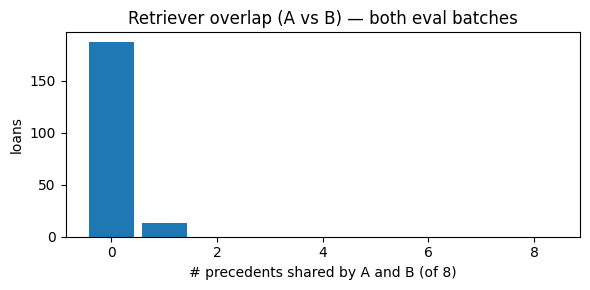

In [6]:
# Overlap pooled across both eval batches (the retriever geometry is batch-independent).
all_A = sum((A_sets[b] for b in EVAL_BATCHES), [])
all_B = sum((B_sets[b] for b in EVAL_BATCHES), [])
overlaps = np.array([len(a & b) for a, b in zip(all_A, all_B)])
jaccard  = np.array([len(a & b) / len(a | b) for a, b in zip(all_A, all_B)])
print(f'Precedents shared by A and B (out of {K_PRECEDENTS}): '
      f'mean {overlaps.mean():.2f}, median {np.median(overlaps):.0f}')
print(f'Mean Jaccard(A top-K, B top-K): {jaccard.mean():.2f}')
print(f'Loans where A and B overlap < 50%: {(jaccard < 0.5).mean() * 100:.0f}%')
print('\nRule of thumb: mean Jaccard < ~0.5 => A and B are complementary, '
      'the hybrid is worth running; >> 0.5 => they largely agree, fusion adds little.')
plt.figure(figsize=(6, 3))
plt.hist(overlaps, bins=range(K_PRECEDENTS + 2), align='left', rwidth=0.85)
plt.xlabel(f'# precedents shared by A and B (of {K_PRECEDENTS})'); plt.ylabel('loans')
plt.title('Retriever overlap (A vs B) — both eval batches'); plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05c_retriever_overlap.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Run the hybrid RAG LLM
⚠️ One API call per loan — set `N_TEST` small first.

In [7]:
rag_system_prompt = R.build_rag_system_prompt()

# One run per eval batch. The batch name is part of the label, so the call cache
# and llm_calls.csv keep tuning/robustness entries separate (never collide).
rag = {}
for bname, df in EVAL_BATCHES.items():
    df_rag, rag_prompt_fn = R.make_rag_prompt_fn(df, blocks[bname])
    rag[bname] = run_llm_experiment(
        df_rag, api_provider=API_PROVIDER, model_name=MODEL_NAME,
        api_keys=API_KEYS, max_workers=MAX_WORKERS, use_cache=not FORCE_RERUN,
        label=f'{MODEL_LABEL} | RAG-C hybrid RRF | {bname}', include_desc=False,
        with_logprobs=WITH_LOGPROBS, system_prompt=rag_system_prompt,
        user_prompt_fn=rag_prompt_fn, notebook_id=NOTEBOOK_ID,
        strict=True, max_fail_frac=0.2,
    )
    print(f'[{bname}] Hybrid RAG metrics:', rag[bname]['metrics'])

[GPT-5.4 | RAG-C hybrid RRF | robustness | no_desc] First call OK (pred=0, prob=0.22270013882530887). Running 100 loans on 10 key(s) × 40 worker(s)...
[GPT-5.4 | RAG-C hybrid RRF | robustness | no_desc] 26/100 done (3s elapsed, ~9s remaining)
[GPT-5.4 | RAG-C hybrid RRF | robustness | no_desc] 51/100 done (5s elapsed, ~5s remaining)
[GPT-5.4 | RAG-C hybrid RRF | robustness | no_desc] 76/100 done (6s elapsed, ~2s remaining)
[GPT-5.4 | RAG-C hybrid RRF | robustness | no_desc] 100/100 done (9s elapsed, ~0s remaining)
[GPT-5.4 | RAG-C hybrid RRF | robustness | no_desc] COMPLETE — 100 predictions, 0 parse errors, 100 with logprobs, 9s total

GPT-5.4 | RAG-C hybrid RRF | robustness (no_desc) Results (100 samples)
Accuracy: 76.0%
AUC:      0.516  (over 100 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.11      0.22      0.14         9
  Fully Paid       0.91      0.81      0.86        91

    accuracy                    

## 6. Baselines — no-RAG LLM and XGBoost (same validation loans)

In [8]:
# No-RAG LLM control — computed ONCE per batch and recycled across 05a/05b/05c.
# The robustness baseline keeps its original file name so the existing saved run
# is recycled with no API calls; the tuning baseline gets its own file.
def _norag_path(bname):
    p = Path(R.NORAG_BASELINE_PATH)
    return p if bname == 'robustness' else p.with_name(f'05_norag_baseline_{bname}_predictions.csv')

base, xgb = {}, {}
for bname, df in EVAL_BATCHES.items():
    base[bname] = R.get_norag_baseline(
        df,
        run_fn=lambda df=df, bname=bname: run_llm_experiment(
            df, api_provider=API_PROVIDER, model_name=MODEL_NAME,
            api_keys=API_KEYS, max_workers=MAX_WORKERS, use_cache=not FORCE_RERUN,
            label=f'{MODEL_LABEL} | no-RAG | {bname}', include_desc=False,
            with_logprobs=WITH_LOGPROBS, notebook_id='05_norag_baseline',
            strict=True, max_fail_frac=0.2,
        ),
        force=FORCE_RERUN, path=_norag_path(bname),
    )
    probs, preds_ = run_ml_on_sample(df)
    xgb[bname] = {'probs': probs, 'preds': preds_,
                  'metrics': evaluate_predictions(df['loan_status'].values, preds_,
                                                  label=f'XGBoost | {bname}',
                                                  probabilities=probs)}


LLM no-RAG Results (100 samples)
Accuracy: 81.0%
AUC:      0.531  (over 100 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.14      0.22      0.17         9
  Fully Paid       0.92      0.87      0.89        91

    accuracy                           0.81       100
   macro avg       0.53      0.55      0.53       100
weighted avg       0.85      0.81      0.83       100

Confusion Matrix:
[[ 2  7]
 [12 79]]
Recycled no-RAG baseline from 05_norag_baseline_predictions.csv — no API calls.

XGBoost | robustness Results (100 samples)
Accuracy: 61.0%
AUC:      0.426  (over 100 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.03      0.11      0.05         9
  Fully Paid       0.88      0.66      0.75        91

    accuracy                           0.61       100
   macro avg       0.46      0.39      0.40       100
weighted avg       0.81      0.6

## 7. Leaderboard + save
Pulls in the Approach A / B rows from `05a_summary.csv` / `05b_summary.csv` if you've run those notebooks, so all five models sit in one table.

In [9]:
METRIC_KEYS = ['accuracy', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off', 'auc']

def _row(name, m, batch):
    return {'model': name, 'batch': batch, **{k: m.get(k) for k in METRIC_KEYS}}

def _pooled(arm_preds, arm_probs, label):
    """Metrics over the two batches concatenated (200 loans, ~24 defaults)."""
    y = np.concatenate([EVAL_BATCHES[b]['loan_status'].values for b in EVAL_BATCHES])
    p = sum((list(arm_preds[b]) for b in EVAL_BATCHES), [])
    pr = sum((list(arm_probs[b]) if arm_probs[b] is not None else [np.nan] * len(EVAL_BATCHES[b])
              for b in EVAL_BATCHES), [])
    return evaluate_predictions(y, p, label=label, probabilities=pr)

rows = []
for bname in EVAL_BATCHES:
    rows.append(_row('RAG-C (hybrid RRF)', rag[bname]['metrics'], bname))
rows.append(_row('RAG-C (hybrid RRF)',
                 _pooled({b: rag[b]['predictions'] for b in EVAL_BATCHES},
                         {b: rag[b]['probabilities'] for b in EVAL_BATCHES}, 'RAG-C pooled'),
                 'pooled'))

# Bring in A and B if their summaries exist (legacy files without a batch column
# are treated as robustness-only runs).
for f in ('05a_summary.csv', '05b_summary.csv'):
    p = f'{RESULTS_DIR}/{f}'
    if os.path.exists(p):
        prev = pd.read_csv(p)
        if 'batch' not in prev.columns:
            prev['batch'] = 'robustness'
        for _, r in prev[prev['model'].str.startswith('RAG-')].iterrows():
            rows.append(r.to_dict())

for bname in EVAL_BATCHES:
    rows += [_row('LLM no-RAG', base[bname]['metrics'], bname),
             _row('XGBoost', xgb[bname]['metrics'], bname)]
rows += [
    _row('LLM no-RAG',
         _pooled({b: base[b]['predictions'] for b in EVAL_BATCHES},
                 {b: base[b]['probabilities'] for b in EVAL_BATCHES}, 'no-RAG pooled'), 'pooled'),
    _row('XGBoost',
         _pooled({b: xgb[b]['preds'] for b in EVAL_BATCHES},
                 {b: xgb[b]['probs'] for b in EVAL_BATCHES}, 'XGBoost pooled'), 'pooled'),
]

summary = (pd.DataFrame(rows)
           .drop_duplicates(subset=['model', 'batch'])
           .reset_index(drop=True))
display(summary.sort_values(['batch', 'f1_charged_off'], ascending=[True, False]))
summary.to_csv(f'{RESULTS_DIR}/05c_summary.csv', index=False)

preds = pd.concat([
    pd.DataFrame({
        'batch':      bname,
        'loan_index': range(len(df)),
        'actual':     df['loan_status'].values,
        'rag_pred':   rag[bname]['predictions'],
        'rag_prob':   rag[bname]['probabilities'],
        'norag_pred': base[bname]['predictions'],
        'norag_prob': base[bname]['probabilities'],
        'xgb_pred':   xgb[bname]['preds'],
        'xgb_prob':   xgb[bname]['probs'],
    })
    for bname, df in EVAL_BATCHES.items()
], ignore_index=True)
preds.to_csv(f'{RESULTS_DIR}/05c_predictions.csv', index=False)
print(f'Saved -> {RESULTS_DIR}/05c_summary.csv  and  05c_predictions.csv')


RAG-C pooled Results (200 samples)
Accuracy: 75.5%
AUC:      0.512  (over 200 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.14      0.21      0.17        24
  Fully Paid       0.88      0.83      0.86       176

    accuracy                           0.76       200
   macro avg       0.51      0.52      0.51       200
weighted avg       0.80      0.76      0.77       200

Confusion Matrix:
[[  5  19]
 [ 30 146]]

no-RAG pooled Results (200 samples)
Accuracy: 81.5%
AUC:      0.591  (over 200 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.28      0.33      0.30        24
  Fully Paid       0.91      0.88      0.89       176

    accuracy                           0.81       200
   macro avg       0.59      0.61      0.60       200
weighted avg       0.83      0.81      0.82       200

Confusion Matrix:
[[  8  16]
 [ 21 155]]

XGBoost pooled R

,model,batch,accuracy,precision_charged_off,recall_charged_off,f1_charged_off,auc
13,LLM no-RAG,pooled,0.815,0.275862,0.333333,0.301887,0.591383
5,RAG-A (SemanticID+multistage),pooled,0.785,0.172414,0.208333,0.188679,0.547112
14,XGBoost,pooled,0.650,0.129032,0.333333,0.186047,0.564394
2,RAG-C (hybrid RRF),pooled,0.755,0.142857,0.208333,0.169492,0.512074
8,RAG-B (full-corpus kNN),pooled,0.765,0.129032,0.166667,0.145455,0.520360
9,LLM no-RAG,robustness,0.810,0.142857,0.222222,0.173913,0.531136
0,RAG-C (hybrid RRF),robustness,0.760,0.105263,0.222222,0.142857,0.515873
6,RAG-B (full-corpus kNN),robustness,0.740,0.095238,0.222222,0.133333,0.499389
3,RAG-A (SemanticID+multistage),robustness,0.800,0.076923,0.111111,0.090909,0.485958
10,XGBoost,robustness,0.610,0.031250,0.111111,0.048780,0.426129


Saved -> /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm/05c_summary.csv  and  05c_predictions.csv


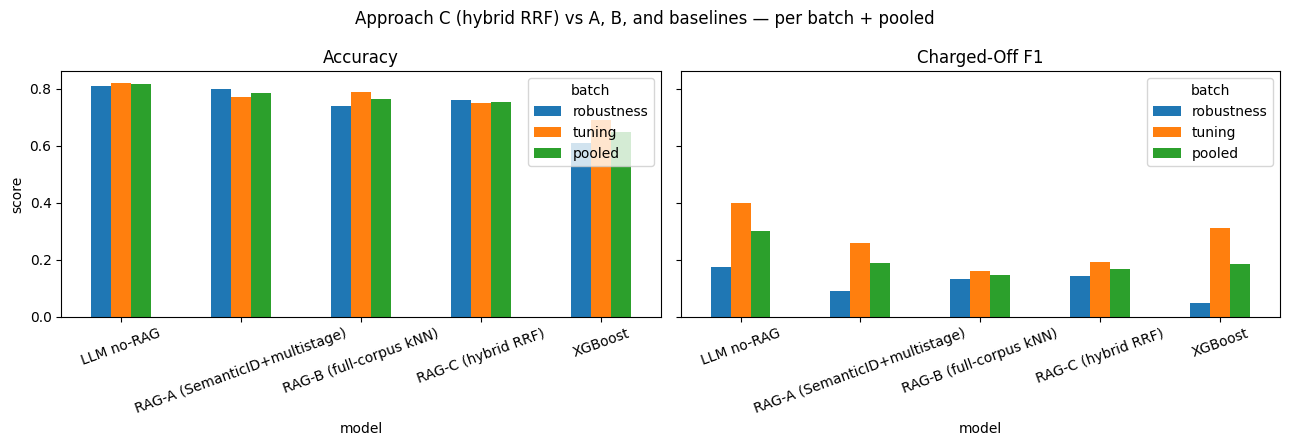

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, metric, title in zip(axes, ['accuracy', 'f1_charged_off'], ['Accuracy', 'Charged-Off F1']):
    (summary.pivot(index='model', columns='batch', values=metric)
            [['robustness', 'tuning', 'pooled']]
            .plot.bar(ax=ax, rot=20))
    ax.set_title(title); ax.set_ylabel('score')
fig.suptitle('Approach C (hybrid RRF) vs A, B, and baselines — per batch + pooled')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05c_comparison.png', dpi=150, bbox_inches='tight'); plt.show()